# SwimHPE Training

Fine-tunes a YOLO-Pose model on the SwimXYZ dataset.

**Sections:**
1. **Mini run** — sample 16 train/16 val images, train for a quick sanity check
2. **Augmentation explorer** — visualise augmented training samples with configurable params
3. **Full training** — train on the complete SwimXYZ train set

### YOLO26-Pose Architecture Overview

**1. Backbone (Layers 0–8): The Feature Extractor**
* **Components:** `Conv` layers, `C3k2` (efficient bottlenecks), `SPPF` (spatial pooling), and `C2PSA` (spatial attention).
* **Role:** Progressively shrinks the image resolution while extracting deep, complex visual patterns. 

**2. Neck (Layers 9-22): The Feature Aggregator**
* **Components:** `Upsample`, `Concat`, and `C3k2` blocks (forming a PANet).
* **Role:** Blends high-resolution spatial details from early layers with deep semantic meaning from later layers.

**3. Head (Layer 23): The Predictor**
* **Components:** End-to-End `Pose` Head.
* **Role:** Outputs final bounding boxes and keypoints. It uses Residual Log-Likelihood Estimation (RLE) for sub-pixel joint precision and completely eliminates the need for Non-Maximum Suppression (NMS) post-processing.


In [1]:
# Install any packages not pre-installed on this runtime (safe to re-run; skipped if already present)
import subprocess, sys

_REQUIRED = ["ultralytics"]
for _pkg in _REQUIRED:
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", _pkg, "-q"], check=True)

In [2]:
import os
import sys
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from ultralytics import YOLO
from ultralytics.utils import SETTINGS

# Must be set before MPS/OpenMP are initialised
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

In [3]:
!nvidia-smi

Wed Mar  4 05:38:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import sys

_IN_COLAB = 'google.colab' in sys.modules

if _IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # ---- Set this to your Drive root (dataset/ must be directly inside) ----
    _ROOT = Path('/content/drive/MyDrive')
    # ------------------------------------------------------------------------
else:
    _ROOT = Path.cwd()
    if _ROOT.name == 'training':
        _ROOT = _ROOT.parent

print(f'Project root: {_ROOT}')
print(f'Running on Colab: {_IN_COLAB}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive
Running on Colab: True


In [5]:
# Disable Ultralytics analytics callbacks that can block between epochs
SETTINGS['sync'] = False

# SETTINGS['datasets_dir'] is read only once at import time into ultralytics.data.utils.DATASETS_DIR.
# Patch the live variable so check_det_dataset() resolves 'path: dataset' against _ROOT,
# not the default /content/datasets.
import ultralytics.data.utils as _ul_data_utils
_ul_data_utils.DATASETS_DIR = Path(_ROOT)

try:
    from ultralytics.utils.events import events as _ul_events
    _ul_events.enabled = False
except Exception:
    pass

In [6]:
def train_and_save(
    model="yolo11n-pose.pt",
    epochs=2,
    device="cpu",
    freeze=9,
    data=None,
    plots=True,
    val=True,
    save=True,
    save_period=0,
    final_val=False,
    close_mosaic=10,
    workers=0,
    name="train",
    resume=False,
    amp=False,
    **aug_kwargs,
):
    """
    Train the model and save the final weights.

    Args:
        model: Ultralytics model identifier or path to weights file.
            Passed directly to YOLO(); auto-downloaded from hub if not found locally.
            Examples: "yolo11n-pose.pt", "yolo11s-pose.pt", "path/to/custom.pt".
        epochs: Number of training epochs.
        device: Device to train on (e.g. "cpu", "0", "mps").
        freeze: Number of top-level backbone/neck blocks to freeze
            (0 = train all, passed directly to model.train()).
        data: Path to the dataset YAML config. Defaults to configs/mixed.yaml.
        plots: Whether to save training/val metric plots to the run directory.
        val: Whether to run validation after each epoch.
        save: Whether to save last.pt/best.pt checkpoints.
        save_period: Save a checkpoint every N epochs (0 = disabled).
        final_val: Whether to run a single validation pass after training.
        close_mosaic: Disable mosaic augmentation for the final N epochs (0 = never).
        workers: Number of dataloader worker processes (0 = main process only, safe default).
        name: Run subdirectory name under project/ (e.g. "train", "full_train").
        resume: If True, resume an interrupted training run from the weights in `model`
            (should be last.pt). Ultralytics will restore the epoch counter, optimizer
            state, and all original hyperparameters from the checkpoint — most other
            parameters to this function are ignored in that case.
        amp: Whether to use automatic mixed precision (FP16). Defaults to False.
            YOLO26-pose requires amp=False — its RealNVP flow model (used for RLE loss)
            is numerically unstable in FP16 and produces NaN inside backward_p(), crashing
            training. Set to True only if you need FP16 speed and have confirmed stability.
        **aug_kwargs: Augmentation overrides passed directly to model.train()
            (e.g. hsv_h=0.015, mosaic=1.0, fliplr=0.5, erasing=0.4).

    Returns:
        Tuple of (best_weights_path, run_dir).
    """
    data = data or str(_ROOT / 'configs/mixed.yaml')

    # save_period requires save=True — Ultralytics only calls save_model() when save=True,
    # and the epochN.pt logic lives inside save_model().
    if save_period > 0:
        save = True

    print(f"Loading model: {model}")
    yolo = YOLO(model)

    # Seed the trainer's callback lists as empty so integration callbacks start from scratch.
    yolo.callbacks["on_fit_epoch_end"] = []
    yolo.callbacks["on_train_end"] = []

    def _suppress_network_callbacks(trainer) -> None:
        # Fires at on_train_start, after add_integration_callbacks() has already appended
        # hub/platform callbacks to the trainer's own dict.
        for key in ("on_fit_epoch_end", "on_train_end", "teardown"):
            trainer.callbacks[key] = []

    yolo.callbacks["on_train_start"].append(_suppress_network_callbacks)

    yolo.train(
        data=data,
        epochs=epochs,
        imgsz=640,
        device=device,
        workers=workers,
        plots=plots,
        val=val,
        save=save,
        save_period=save_period,
        freeze=freeze,
        close_mosaic=close_mosaic,
        project=str(_ROOT / 'runs'),
        name=name,
        resume=resume,
        amp=amp,
        **aug_kwargs,
    )

    run_dir = Path(yolo.trainer.save_dir)
    best_pt = run_dir / 'weights' / 'best.pt'
    print("\n✅ Training complete.")
    print(f"   Run artifacts : {run_dir}")
    print(f"   Best weights  : {best_pt}")

    if final_val:
        print("\nRunning final validation...")
        yolo.val(data=data, device=device)

    return str(best_pt), run_dir

In [7]:
# Pairs of (title, train_col, val_col) — missing columns are silently skipped
_LOSS_PANELS = [
    ("Box loss",       "train/box_loss",  "val/box_loss"),
    ("Pose loss",      "train/pose_loss", "val/pose_loss"),
    ("Keypoint obj.",  "train/kobj_loss", "val/kobj_loss"),
    ("Class loss",     "train/cls_loss",  "val/cls_loss"),
    ("DFL loss",       "train/dfl_loss",  "val/dfl_loss"),
]

_METRIC_PANELS = [
    ("Box mAP50",       "metrics/mAP50(B)",    None),
    ("Box mAP50-95",    "metrics/mAP50-95(B)", None),
    ("Pose mAP50",      "metrics/mAP50(P)",    None),
    ("Pose mAP50-95",   "metrics/mAP50-95(P)", None),
    ("Precision (box)", "metrics/precision(B)", None),
    ("Recall (box)",    "metrics/recall(B)",    None),
]


def plot_training_results(run_dir):
    """Read results.csv from run_dir and display loss + metric curves."""
    csv_path = run_dir / 'results.csv'
    if not csv_path.exists():
        print(f"⚠️  results.csv not found at {csv_path}. Skipping plots.")
        return

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    epochs = df['epoch'] if 'epoch' in df.columns else range(len(df))

    available_loss    = [(t, tc, vc) for t, tc, vc in _LOSS_PANELS if tc in df.columns]
    available_metrics = [(t, mc, _) for t, mc, _ in _METRIC_PANELS if mc in df.columns]
    all_panels = available_loss + available_metrics

    if not all_panels:
        print("⚠️  No recognised columns found in results.csv. Available columns:")
        print("   ", list(df.columns))
        return

    ncols = 3
    nrows = (len(all_panels) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else list(axes)
    fig.suptitle(f"Training results — {run_dir.name}", fontsize=13, fontweight='bold')

    for ax, (title, train_col, val_col) in zip(axes, all_panels):
        ax.plot(epochs, df[train_col], label='train', linewidth=1.5)
        if val_col and val_col in df.columns:
            ax.plot(epochs, df[val_col], label='val', linewidth=1.5, linestyle='--')
        ax.set_title(title)
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    for ax in axes[len(all_panels):]:
        ax.set_visible(False)

    plt.tight_layout()
    out_path = run_dir / 'loss_curves.png'
    plt.savefig(out_path, dpi=150)
    print(f"✅ Loss/metric curves saved to {out_path}")

    results_png = run_dir / 'results.png'
    if results_png.exists():
        print(f"   Ultralytics results.png: {results_png}")

    plt.show()

---
## Augmentation Explorer

Visualise what augmented training samples look like **before** committing to a set of hyperparameters.

Edit the `AUG` dictionary in the cell below, then run it to see a grid of samples produced by the exact same pipeline used during training (mosaic, HSV jitter, perspective, fliplr with the correct keypoint `flip_idx`, erasing, etc.).

| Param | Default | Range | Effect |
|---|---|---|---|
| `hsv_h` | 0.015 | 0–1 | Hue shift |
| `hsv_s` | 0.70 | 0–1 | Saturation jitter |
| `hsv_v` | 0.40 | 0–1 | Brightness jitter |
| `degrees` | 15.0 | 0–180 | Rotation ± degrees |
| `translate` | 0.10 | 0–1 | H/V translation fraction |
| `scale` | 0.50 | 0–1 | Scale gain (0.5 → 0.5×–1.5×) |
| `shear` | 0.0 | 0–180 | Shear ± degrees |
| `perspective` | 0.0 | 0–0.001 | Perspective warp |
| `flipud` | 0.0 | 0–1 | Vertical flip probability |
| `fliplr` | 0.5 | 0–1 | Horizontal flip probability |
| `bgr` | 0.0 | 0–1 | BGR channel swap probability |
| `mosaic` | 1.0 | 0–1 | 4-image mosaic probability |
| `mixup` | 0.0 | 0–1 | MixUp blend probability |
| `erasing` | 0.4 | 0–1 | Random region erasure probability |

train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1102.1±371.7 MB/s, size: 30.0 KB)
train: Scanning /tmp/tmpdzn0s9sd/labels/train... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 857.4it/s 0.1s
train: New cache created: /tmp/tmpdzn0s9sd/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


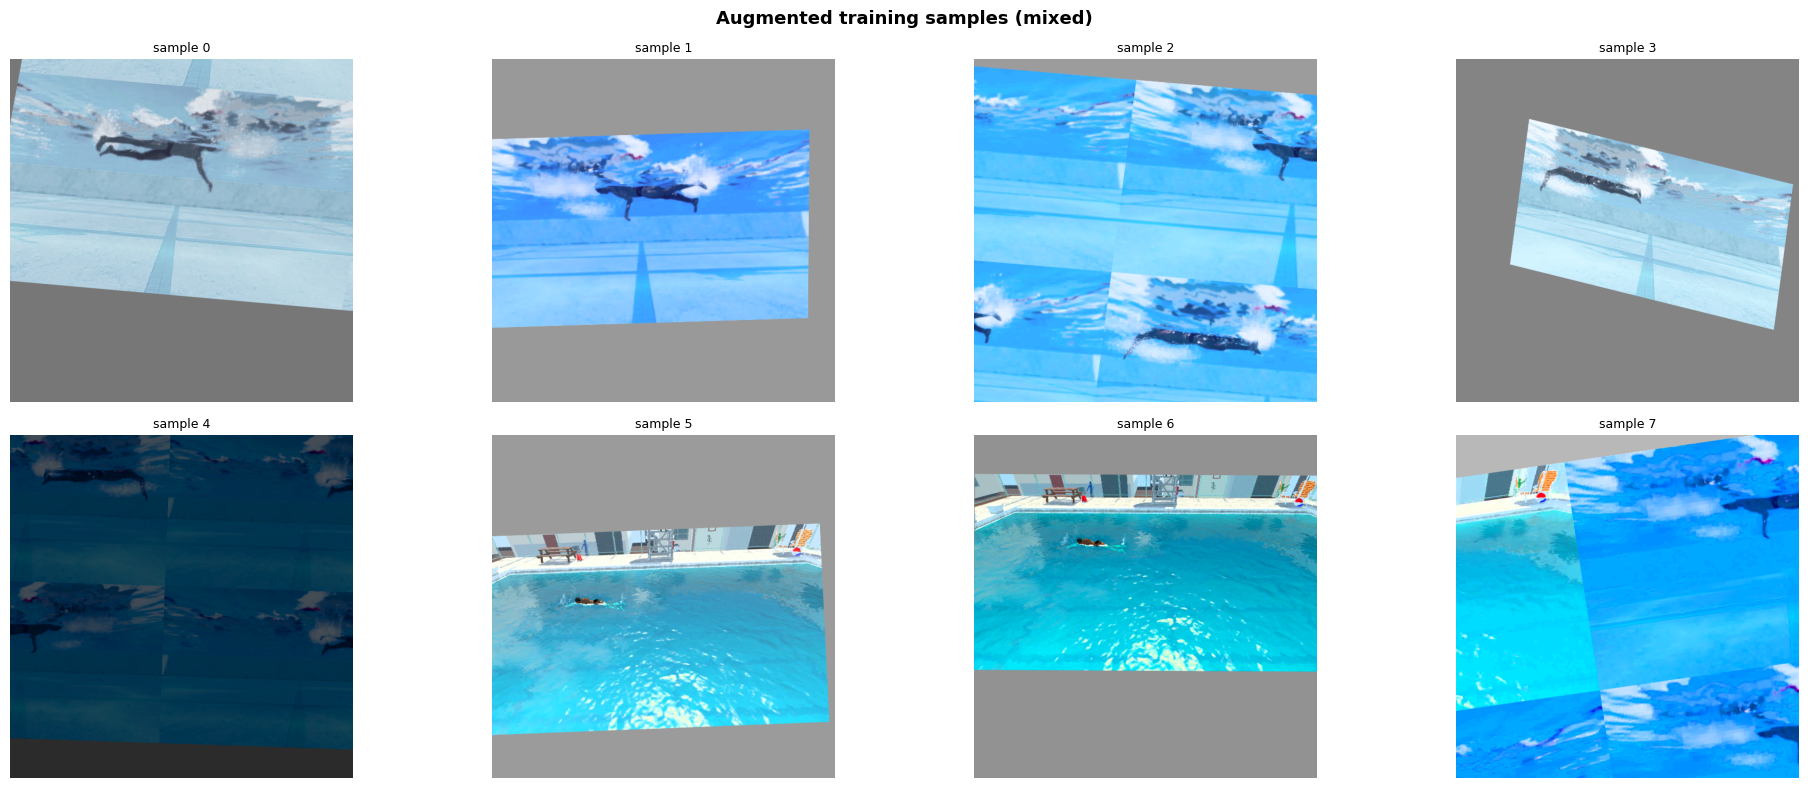

In [8]:
import yaml as _yaml
import tempfile as _tempfile
import shutil as _shutil
import numpy as np
from types import SimpleNamespace
from ultralytics.data.build import build_yolo_dataset

# ── Edit these augmentation params, then re-run the cell ──────────────────
AUG = dict(
    hsv_h        = 0.015,   # Hue shift (0–1)
    hsv_s        = 0.70,    # Saturation jitter (0–1)
    hsv_v        = 0.70,    # Brightness jitter (0–1)
    degrees      = 10.0,    # Rotation ± degrees (0–180)
    translate    = 0.10,    # H/V translation as fraction (0–1)
    scale        = 0.25,    # Scale gain (0.5 → 0.5×–1.5×)
    shear        = 5,     # Shear ± degrees (0–180)
    perspective  = 0.0,     # Perspective warp (0–0.001, keep small)
    flipud       = 0.0,     # Vertical flip probability (0–1)
    fliplr       = 0.25,     # Horizontal flip probability (0–1)
    bgr          = 0.1,     # BGR channel-swap probability (0–1)
    mosaic       = 0.25,     # 4-image mosaic probability (0–1)
    mixup        = 0.0,     # MixUp blend probability (0–1)
    erasing      = 0.5,     # Random region erasure probability (0–1)
)

N_SAMPLE = 64  # images to copy from main dataset into /tmp for fast scanning
N_IMAGES = 8   # augmented samples to display (must be <= N_SAMPLE)
N_COLS   = 4
# ──────────────────────────────────────────────────────────────────────────

# Load main dataset config
data_cfg = str(_ROOT / 'configs' / 'mixed.yaml')
with open(data_cfg) as _f:
    data_dict = _yaml.safe_load(_f)
data_dict['path'] = str(_ROOT / data_dict.get('path', 'dataset'))

# Pick N_SAMPLE random images+labels and stage them in /tmp (fast local storage).
# This avoids scanning all label files over Drive FUSE.
_src_img  = Path(data_dict["path"]) / data_dict["train"]
_src_lbl  = Path(data_dict["path"]) / data_dict["train"].replace("images", "labels")
_all_imgs = sorted(_src_img.glob("*"))
_chosen   = random.sample(_all_imgs, min(N_SAMPLE, len(_all_imgs)))

_tmp = Path(_tempfile.mkdtemp())
(_tmp / "images" / "train").mkdir(parents=True)
(_tmp / "labels" / "train").mkdir(parents=True)
for _img in _chosen:
    _shutil.copy2(_img, _tmp / "images" / "train" / _img.name)
    _lbl = _src_lbl / _img.with_suffix(".txt").name
    if _lbl.exists():
        _shutil.copy2(_lbl, _tmp / "labels" / "train" / _lbl.name)

cfg = SimpleNamespace(
    task="pose", mode="train",
    imgsz=640, rect=False, cache=False,
    single_cls=False, fraction=1.0, pad=0.5,
    overlap_mask=True, mask_ratio=4,
    close_mosaic=0, classes=None,
    copy_paste=0.0, copy_paste_mode="flip",
    cutmix=0.0,
    **AUG,
)

_tmp_data = {**data_dict, "path": str(_tmp)}
img_path  = str(_tmp / "images" / "train")
dataset   = build_yolo_dataset(cfg, img_path, batch=N_IMAGES, data=_tmp_data, mode="train")

n_rows = (N_IMAGES + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(5 * N_COLS, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else list(axes)
fig.suptitle("Augmented training samples (mixed)", fontsize=13, fontweight="bold")

for i, ax in enumerate(axes):
    if i >= N_IMAGES:
        ax.set_visible(False)
        continue
    sample = dataset[i % len(dataset)]
    img = sample["img"]
    if isinstance(img, torch.Tensor):
        img = img.numpy()
    img = img.transpose(1, 2, 0)  # CHW → HWC
    if img.dtype != np.uint8:
        img = (img * 255).clip(0, 255).astype(np.uint8)
    ax.imshow(img)               # already RGB from Ultralytics pipeline
    ax.set_title(f"sample {i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## Full Training

Trains on the complete SwimXYZ train set using `configs/swimXYZ.yaml`.

**Before running:** tune the `AUG` dict in the Augmentation Explorer cell above and copy the values you want into the `model.train()` call below.

**Tip:** lower `FREEZE` (e.g. `5`) or set to `0` to train all layers if the mini run shows underfitting.

Device: cuda
Loading model: yolo26n-pose.pt
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.05, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/configs/mixed.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.5, exist_ok=False, fliplr=0.25, flipud=0.0, format=torchscript, fraction=1.0, freeze=9, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.7, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=0.25, multi_scale=0.0, name=full_train3, nbs=64, nms=False, opset=None, optimize=

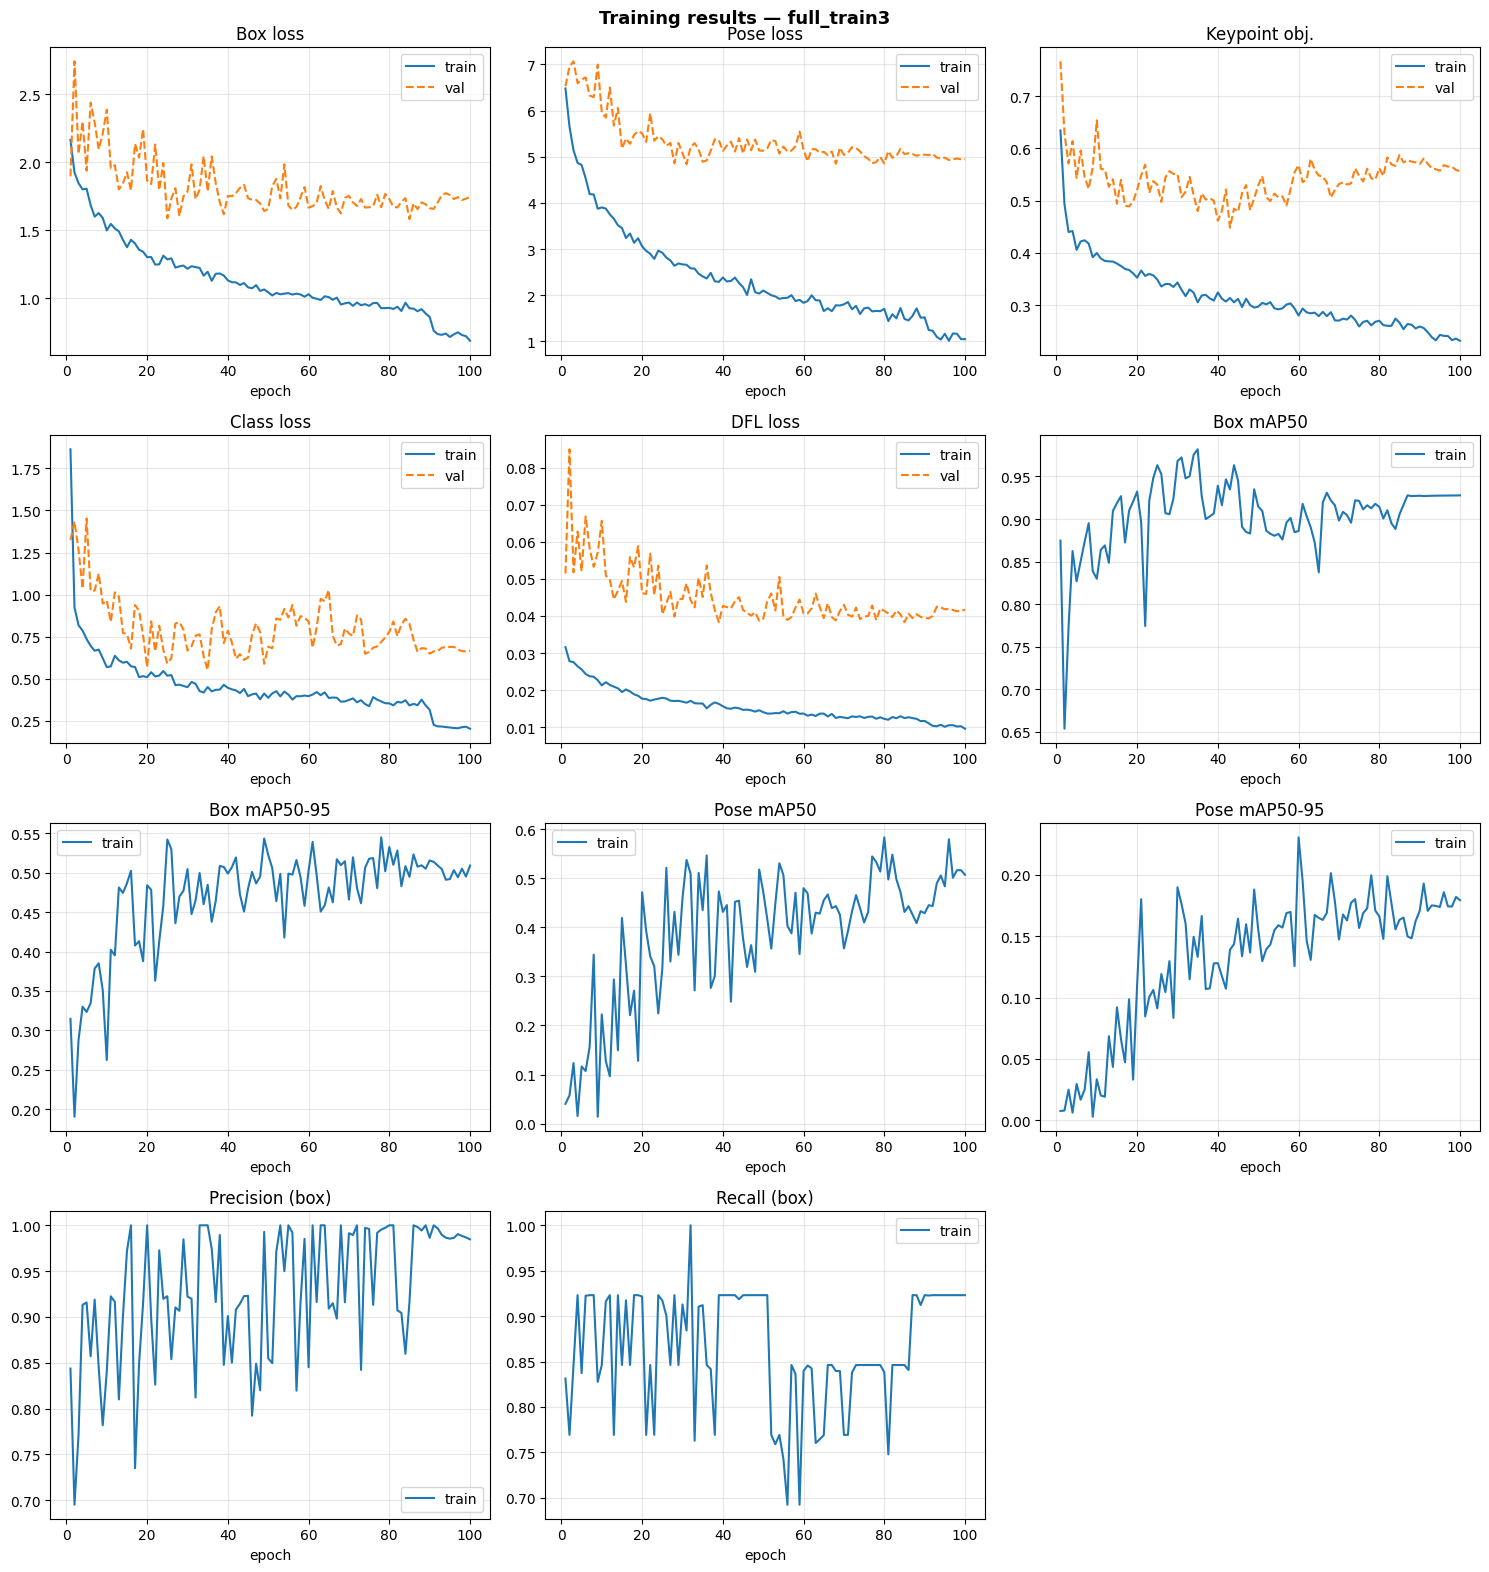

In [9]:
# ── Full training config ───────────────────────────────────────────────────
MODEL        = 'yolo26n-pose.pt'   # base model to fine-tune
# To continue from existing Drive weights, set RESUME_FROM to the .pt path:
#   RESUME_FROM = str(_ROOT / 'runs/full_train/weights/best.pt')  # fine-tune (epoch resets to 1)
#   RESUME_FROM = str(_ROOT / 'runs/full_train/weights/last.pt')  # interrupted run (see below)
RESUME_FROM  = False #str(_ROOT / 'runs/full_train3/weights/best.pt')
EPOCHS       = 100
FREEZE       = 9     # backbone/neck blocks to freeze from the start (0 = train all)
CLOSE_MOSAIC = 10    # disable mosaic for the final N epochs
SAVE_PERIOD  = 25    # save a checkpoint every N epochs (0 = only final)

# Paste your tuned AUG values from the explorer above (or leave as defaults)
FULL_AUG =  dict(
    hsv_h        = 0.015,   # Hue shift (0–1)
    hsv_s        = 0.70,    # Saturation jitter (0–1)
    hsv_v        = 0.70,    # Brightness jitter (0–1)
    degrees      = 10.0,    # Rotation ± degrees (0–180)
    translate    = 0.10,    # H/V translation as fraction (0–1)
    scale        = 0.25,    # Scale gain (0.5 → 0.5×–1.5×)
    shear        = 5,       # Shear ± degrees (0–180)
    perspective  = 0.0,     # Perspective warp (0–0.001, keep small)
    flipud       = 0.0,     # Vertical flip probability (0–1)
    fliplr       = 0.25,    # Horizontal flip probability (0–1)
    bgr          = 0.05,     # BGR channel-swap probability (0–1)
    mosaic       = 0.25,    # 4-image mosaic probability (0–1)
    mixup        = 0.0,     # MixUp blend probability (0–1)
    erasing      = 0.5,     # Random region erasure probability (0–1)
)
# ──────────────────────────────────────────────────────────────────────────

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

_weights_path, run_dir = train_and_save(
    model=RESUME_FROM or MODEL,
    resume=False,
    epochs=EPOCHS,
    device=device,
    freeze=FREEZE,
    close_mosaic=CLOSE_MOSAIC,
    workers=4,
    plots=True,
    val=True,
    save=True,
    name="full_train",
    save_period=SAVE_PERIOD,
    **FULL_AUG,
)

plot_training_results(run_dir)